## 1. Introduction & Setup

we build a simple, linear-regression–based model that predicts an **approximate next-day intraday move** in SPY (S&P 500 ETF), and converts that into a **BUY/SELL signal**.

High-level design:

- Use **daily Yahoo Finance data** (SPY, QQQ, GLD, USO, TLT, SHY, ^VIX, DX-Y.NYB).
- Engineer features including:
  - SPY-specific technicals (returns, RSI, distance to MA, volume z-score).
  - Cross-asset / macro features (QQQ, gold, oil, bonds, VIX, DXY, correlations).
  - Time-lagged versions of these features.
- Target: **next-day close-to-close return** of SPY, which we use as a proxy for the 9:30 → 16:00 move.
- Use **linear regression** in a scikit-learn `Pipeline` with scaling.
- Use **time-series-aware train/validation split** and cross-validation.
- Build an **inference pipeline** that:
  - Downloads latest data.
  - Rebuilds features and lags identically to training.
  - Predicts next-day return, then maps this back to an approximate 9:30 price and 16:00 price.
  - Generates a **BUY** if predicted 16:00 price > 9:30 price, else **SELL**.
- Save model + metadata to a `.pkl` file and create a `requirements.txt`.

In [2]:
%pip install yfinance numpy pandas matplotlib scikit-learn 

  Using cached yfinance-0.2.66-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached numpy-2.3.5-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached matplotlib-3.10.7-cp314-cp314-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached scikit_learn-1.7.2-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached multitasking-0.0.12-py3-none-any.whl
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached peewee-3.18.3-cp314-cp314-macosx_26_0_arm64.whl
  Using cached beautifulsoup4-4.14.2-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached protobuf-6.33.1-cp39-abi3-macosx_10_9_universal2.whl.metadata (593 bytes)
  Using cached websockets-15.0.1-py3-none-any.whl.

In [3]:
# 1.1 Core imports and global configuration

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import pickle
import os

# If yfinance is not installed, uncomment the following line:
# !pip install yfinance

import yfinance as yf

plt.style.use("default")  # use a simple default style

## 2. Data Ingestion from Yahoo Finance

In this section we:

1. Define the tickers we need.
2. Download **daily OHLCV data** from Yahoo Finance over a multi-year window.
3. Keep everything in a single `pandas.DataFrame` with a common **date index**.

We will use:

- `SPY` — S&P 500 ETF  
- `QQQ` — Nasdaq-100 ETF  
- `GLD` — Gold ETF (proxy for gold)  
- `USO` — Oil ETF (proxy for crude oil)  
- `TLT` — Long-duration US Treasuries ETF  
- `SHY` — Short-term US Treasuries ETF  
- `^VIX` — CBOE Volatility Index  
- `DX-Y.NYB` — ICE US Dollar Index on Yahoo Finance  

We’ll fetch about 10 years of daily data by default (you can adjust `start_date`).

In [4]:
# 2.1 Download helper

TICKERS = {
    "SPY": "SPY",
    "QQQ": "QQQ",
    "GOLD": "GLD",
    "OIL": "USO",
    "TLT": "TLT",
    "SHY": "SHY",
    "VIX": "^VIX",
    "DXY": "DX-Y.NYB",  # US Dollar Index on Yahoo
}

def download_price_data(
    tickers_dict,
    start_date="2015-01-01",
    end_date=None,
    auto_adjust=True,
):
    """
    Download daily OHLCV data for all tickers using yfinance.

    Parameters
    ----------
    tickers_dict : dict
        Mapping of logical names -> yfinance tickers.
    start_date : str
        Start date 'YYYY-MM-DD'.
    end_date : str or None
        End date; None = today.
    auto_adjust : bool
        If True, adjust for splits/dividends.

    Returns
    -------
    prices : pd.DataFrame
        MultiIndex columns: (symbol, field) with a DatetimeIndex.
    """
    yf_tickers = " ".join(tickers_dict.values())
    data = yf.download(
        yf_tickers,
        start=start_date,
        end=end_date,
        auto_adjust=auto_adjust,
        group_by="ticker",
        progress=False
    )

    # Ensure MultiIndex columns even if only one ticker
    if isinstance(data.columns, pd.MultiIndex):
        prices = data
    else:
        # Single ticker case: wrap into MultiIndex
        symbol = list(tickers_dict.keys())[0]
        prices = pd.concat({symbol: data}, axis=1)

    # Sort columns for consistency
    prices = prices.sort_index(axis=1)
    return prices

# 2.2 Actually download the data

start_date = "2015-01-01"
raw_prices = download_price_data(TICKERS, start_date=start_date)

raw_prices.head()

Ticker       DX-Y.NYB                                                 GLD  \
Price           Close       High        Low       Open Volume       Close   
Date                                                                        
2015-01-02  91.080002  91.160004  90.330002  90.360001    0.0  114.080002   
2015-01-05  91.379997  91.779999  91.129997  91.129997    0.0  115.800003   
2015-01-06  91.500000  91.809998  91.120003  91.379997    0.0  117.120003   
2015-01-07  91.889999  92.269997  91.650002  91.750000    0.0  116.430000   
2015-01-08  92.370003  92.529999  91.940002  91.940002    0.0  115.940002   

Ticker                                                      ...         USO  \
Price             High         Low        Open      Volume  ...       Close   
Date                                                        ...               
2015-01-02  114.800003  112.320000  112.489998   7109600.0  ...  159.119995   
2015-01-05  116.000000  114.730003  114.779999   8177400.0  ...  150.320007   
2015-01-06  117.500000  115.800003  116.220001  11238300.0  ...  144.399994   
2015-01-07  116.879997  116.169998  116.470001   6434200.0  ...  146.960007   
2015-01-08  116.870003  115.849998  116.449997   7033700.0  ...  148.399994   

Ticker                                                          ^VIX  \
Price             High         Low        Open     Volume      Close   
Date                                                                   
2015-01-02  162.800003  157.520004  159.759995  2638313.0  17.790001   
2015-01-05  154.880005  150.320007  154.639999  3937438.0  19.920000   
2015-01-06  149.600006  144.000000  148.479996  5279375.0  21.120001   
2015-01-07  149.199997  144.399994  146.399994  3916575.0  19.309999   
2015-01-08  148.720001  144.479996  146.240005  3338188.0  17.010000   

Ticker                                              
Price            High        Low       Open Volume  
Date                                                
2015-01-02  20.139999  17.049999  17.760000    0.0  
2015-01-05  21.290001  19.190001  19.190001    0.0  
2015-01-06  22.900000  19.520000  20.330000    0.0  
2015-01-07  20.719999  19.040001  20.150000    0.0  
2015-01-08  18.090000  16.990000  17.930000    0.0  

[5 rows x 40 columns]

## 3. Feature Engineering (Base Features)

Here we build the **base feature set** (before adding lags):

Core SPY features:

- `spy_ret_1d` — 1-day SPY return
- `spy_ret_5d` — 5-day SPY return
- `spy_rsi14` — 14-day RSI on SPY
- `spy_dist_ma20` — distance from 20-day moving average (we’ll use % distance)
- `spy_vol_z20` — 20-day z-score of SPY volume

Cross-asset / macro features:

- `qqq_ret_5d`
- `qqq_over_spy_ratio`
- `gold_ret_5d`
- `oil_ret_5d`
- `tlt_ret_5d`
- `shy_ret_5d`
- `tlt_shy_spread` (5-day TLT return − 5-day SHY return)
- `vix_lvl` (VIX level)
- `vix_chg_5d` (5-day change in VIX level, %)
- `dxy_ret_5d`
- `spy_corr_gold_20` (20-day rolling correlation of SPY and gold)
- `spy_corr_qqq_20` (20-day rolling correlation of SPY and QQQ)
- `curve_proxy_tlt_shy` (log price ratio TLT/SHY, a crude yield-curve proxy)
- `inflation_proxy_oil_minus_gold` (oil 5d return − gold 5d return)
- `riskoff_proxy_vix_plus_dxy` (z-scored VIX + z-scored DXY, 60-day window)

We will:

1. Implement a small helper to compute RSI.
2. Build all these features into a single `features_df` indexed by date.
3. Drop dates where we don’t yet have enough history for rolling windows.

In [5]:
# 3.1 Helper: Relative Strength Index (RSI)

def compute_rsi(series, window=14):
    """
    Compute RSI (Relative Strength Index) for a price series.
    Uses the classic Wilder's smoothing approach.

    Parameters
    ----------
    series : pd.Series
        Price series (e.g., close).
    window : int
        Lookback period for RSI.

    Returns
    -------
    rsi : pd.Series
        RSI values (0-100).
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

In [6]:
# 3.2 Compute base features from raw_prices

def compute_base_features(raw):
    """
    Compute all base (non-lagged) features from raw price data.

    Parameters
    ----------
    raw : pd.DataFrame
        MultiIndex columns: (symbol, field).

    Returns
    -------
    features : pd.DataFrame
        Base feature matrix indexed by date.
    spy_close : pd.Series
        SPY adjusted close price (for target construction later).
    """
    # Extract per-symbol data for convenience
    spy = raw[TICKERS["SPY"]] if ("SPY", "Close") in raw.columns else raw["SPY"]
    qqq = raw[TICKERS["QQQ"]] if ("QQQ", "Close") in raw.columns else raw["QQQ"]
    gld = raw[TICKERS["GOLD"]] if ("GLD", "Close") in raw.columns else raw["GOLD"]
    uso = raw[TICKERS["OIL"]] if ("USO", "Close") in raw.columns else raw["OIL"]
    tlt = raw[TICKERS["TLT"]] if ("TLT", "Close") in raw.columns else raw["TLT"]
    shy = raw[TICKERS["SHY"]] if ("SHY", "Close") in raw.columns else raw["SHY"]
    vix = raw[TICKERS["VIX"]] if ("^VIX", "Close") in raw.columns else raw["^VIX"]
    dxy = raw[TICKERS["DXY"]] if ("DX-Y.NYB", "Close") in raw.columns else raw["DX-Y.NYB"]

    def get_close(df):
        return df["Adj Close"] if "Adj Close" in df.columns else df["Close"]

    # We'll work with Adjusted Close and Volume where applicable
    spy_close = get_close(spy).copy()
    spy_vol = spy["Volume"].copy()

    qqq_close = get_close(qqq).copy()
    gld_close = get_close(gld).copy()
    uso_close = get_close(uso).copy()
    tlt_close = get_close(tlt).copy()
    shy_close = get_close(shy).copy()
    vix_close = get_close(vix).copy()
    dxy_close = get_close(dxy).copy()

    # Initialize features DataFrame on SPY's index
    features = pd.DataFrame(index=spy_close.index)

    # --- SPY-specific features ---
    features["spy_ret_1d"] = spy_close.pct_change(1)
    features["spy_ret_5d"] = spy_close.pct_change(5)

    features["spy_rsi14"] = compute_rsi(spy_close, window=14)

    ma20 = spy_close.rolling(window=20).mean()
    features["spy_dist_ma20"] = (spy_close - ma20) / ma20

    vol_mean20 = spy_vol.rolling(window=20).mean()
    vol_std20 = spy_vol.rolling(window=20).std()
    features["spy_vol_z20"] = (spy_vol - vol_mean20) / vol_std20

    # --- Cross-asset features ---
    features["qqq_ret_5d"] = qqq_close.pct_change(5)
    features["qqq_over_spy_ratio"] = qqq_close / spy_close

    features["gold_ret_5d"] = gld_close.pct_change(5)
    features["oil_ret_5d"] = uso_close.pct_change(5)

    features["tlt_ret_5d"] = tlt_close.pct_change(5)
    features["shy_ret_5d"] = shy_close.pct_change(5)
    features["tlt_shy_spread"] = features["tlt_ret_5d"] - features["shy_ret_5d"]

    features["vix_lvl"] = vix_close
    features["vix_chg_5d"] = vix_close.pct_change(5)

    features["dxy_ret_5d"] = dxy_close.pct_change(5)

    # Rolling correlations (20-day) on daily returns
    spy_daily_ret = spy_close.pct_change(1)
    gld_daily_ret = gld_close.pct_change(1)
    qqq_daily_ret = qqq_close.pct_change(1)

    features["spy_corr_gold_20"] = (
        spy_daily_ret.rolling(window=20).corr(gld_daily_ret)
    )
    features["spy_corr_qqq_20"] = (
        spy_daily_ret.rolling(window=20).corr(qqq_daily_ret)
    )

    # Curve proxy - log price ratio (TLT/SHY) ~ long vs short duration
    features["curve_proxy_tlt_shy"] = np.log(tlt_close / shy_close)

    # Inflation proxy - oil outperforming gold
    features["inflation_proxy_oil_minus_gold"] = (
        features["oil_ret_5d"] - features["gold_ret_5d"]
    )

    # Risk-off proxy - standardized VIX + standardized DXY
    vix_z = (vix_close - vix_close.rolling(60).mean()) / vix_close.rolling(60).std()
    dxy_ret_5d = features["dxy_ret_5d"]
    dxy_z = (dxy_ret_5d - dxy_ret_5d.rolling(60).mean()) / dxy_ret_5d.rolling(60).std()
    features["riskoff_proxy_vix_plus_dxy"] = vix_z + dxy_z

    # Drop rows with insufficient history for rolling stats
    features = features.dropna()

    return features, spy_close

# 3.3 Compute base features

base_features, spy_close = compute_base_features(raw_prices)
base_features.head()

,spy_ret_1d,spy_ret_5d,spy_rsi14,spy_dist_ma20,spy_vol_z20,qqq_ret_5d,qqq_over_spy_ratio,gold_ret_5d,oil_ret_5d,tlt_ret_5d,shy_ret_5d,tlt_shy_spread,vix_lvl,vix_chg_5d,dxy_ret_5d,spy_corr_gold_20,spy_corr_qqq_20,curve_proxy_tlt_shy,inflation_proxy_oil_minus_gold,riskoff_proxy_vix_plus_dxy
Date,,,,,,,,,,,,,,,,,,,,
2015-04-07,-0.002646,-0.004658,49.055123,0.001481,-1.108117,-0.008714,0.563811,0.020747,0.106210,0.007319,0.001262,0.006057,14.78,0.018608,-0.001531,0.186192,0.934369,0.338539,0.085463,-1.129873
2015-04-08,0.003377,0.007509,51.071452,0.003915,-0.817321,0.009849,0.566375,0.015925,0.073040,0.005467,0.000437,0.005030,13.98,-0.085677,-0.002948,0.096038,0.911478,0.338844,0.057116,-1.525636
2015-04-09,0.004424,0.015556,53.667061,0.007065,-0.865795,0.021514,0.567423,-0.008045,0.025597,-0.020435,-0.000353,-0.020081,13.09,-0.133686,0.009879,0.050110,0.912748,0.326149,0.033642,-0.940963
2015-04-10,0.005457,0.017438,56.730054,0.011620,-1.129036,0.025019,0.566657,0.005985,0.048405,-0.008491,-0.000472,-0.008019,12.58,-0.142468,0.020012,0.106826,0.926069,0.327852,0.042420,-0.413555
2015-04-13,-0.004523,0.006063,53.552842,0.006033,-0.984472,0.014153,0.567806,-0.013283,0.003798,-0.001538,-0.000706,-0.000832,13.94,-0.054274,0.024508,0.142244,0.924799,0.328650,0.017081,0.463866


## 4. Time-Lagged Features & Target Construction

Now we:

1. Create **time-lagged versions** of each base feature.  
   - Here we use lags of 1, 2, and 5 trading days.
   - Intuition:
     - Lag 1: “yesterday’s information”
     - Lag 2: “two days ago”
     - Lag 5: “one trading week ago”
2. Construct the **target** for linear regression:
   - We choose **next-day close-to-close return** of SPY:
     $$ y_{t+1} = \frac{C_{t+1}}{C_t} - 1 $$
   - We treat this as an approximation to the 9:30 → 16:00 move on the next trading day.
   - At inference, we will approximate the 9:30 price for the next day as today’s close, and map the predicted return to a predicted 16:00 price.
3. Make sure there is **no look-ahead bias**:
   - Features at date \( t \) (including their lags) use only information up to and including \( t \).

- The target is:
$$
y_{t+1}
$$
which is the **next-day return**.

In [9]:
# 4.1 Add time-lagged features

LAGS = [1, 2, 5]  # you can tune these

def add_lagged_features(features, lags=LAGS):
    """
    Given a DataFrame of base features, append lagged versions of each column.

    For each column 'col' and lag k, we create 'col_lag{k}' = col.shift(k).

    Parameters
    ----------
    features : pd.DataFrame
        Base features indexed by date.
    lags : list[int]
        Lags in days.

    Returns
    -------
    features_with_lags : pd.DataFrame
        Features including original columns and their lags.
    """
    features_lagged = features.copy()
    for col in features.columns:
        for lag in lags:
            features_lagged[f"{col}_lag{lag}"] = features[col].shift(lag)
    # Drop rows with NaNs introduced by lags
    features_lagged = features_lagged.dropna()
    return features_lagged

lagged_features = add_lagged_features(base_features, lags=LAGS)
lagged_features.head()

,spy_ret_1d,spy_ret_5d,spy_rsi14,spy_dist_ma20,spy_vol_z20,qqq_ret_5d,qqq_over_spy_ratio,gold_ret_5d,oil_ret_5d,tlt_ret_5d,...,spy_corr_qqq_20_lag5,curve_proxy_tlt_shy_lag1,curve_proxy_tlt_shy_lag2,curve_proxy_tlt_shy_lag5,inflation_proxy_oil_minus_gold_lag1,inflation_proxy_oil_minus_gold_lag2,inflation_proxy_oil_minus_gold_lag5,riskoff_proxy_vix_plus_dxy_lag1,riskoff_proxy_vix_plus_dxy_lag2,riskoff_proxy_vix_plus_dxy_lag5
Date,,,,,,,,,,,,,,,,,,,,,
2015-04-14,0.001913,0.010662,54.703340,0.007512,-0.881381,0.012949,0.565087,-0.014383,-0.012592,-0.002822,...,0.934369,0.328650,0.327852,0.338539,0.017081,0.042420,0.085463,0.463866,-0.413555,-1.129873
2015-04-15,0.004487,0.011780,57.375043,0.011208,-0.304548,0.011253,0.566080,-0.000346,0.090758,-0.003965,...,0.911478,0.335242,0.328650,0.338844,0.001791,0.017081,0.057116,-0.727245,0.463866,-1.525636
2015-04-16,-0.000285,0.007037,57.143396,0.010714,-1.084293,0.003541,0.565453,0.003139,0.105935,0.004095,...,0.912748,0.334400,0.335242,0.326149,0.091105,0.001791,0.033642,-1.599999,-0.727245,-0.940963
2015-04-17,-0.011504,-0.009950,48.616190,-0.000764,2.196765,-0.016149,0.563110,-0.003191,0.077675,0.014118,...,0.926069,0.328940,0.334400,0.327852,0.102795,0.091105,0.042420,-3.049579,-1.599999,-0.413555
2015-04-20,0.009137,0.003635,54.373069,0.008502,-0.334523,0.001117,0.566381,-0.003648,0.075135,0.003775,...,0.924799,0.340810,0.328940,0.328650,0.080866,0.102795,0.017081,-2.376371,-3.049579,0.463866


In [10]:
# 4.2 Build the supervised dataset (X, y)

def build_dataset(features, spy_close, forward_horizon=1):
    """
    Build feature matrix X and target vector y for next-day returns.

    We define target as:
        y_t = (C_{t+forward_horizon} / C_t) - 1

    Features at date t use info up to date t (including lags),
    and are used to predict y_t for the next forward_horizon days.

    Parameters
    ----------
    features : pd.DataFrame
        Features indexed by date (including lags).
    spy_close : pd.Series
        SPY adjusted close prices indexed by date.
    forward_horizon : int
        How many days ahead to predict.

    Returns
    -------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Target next-day (or horizon) return.
    full_df : pd.DataFrame
        Combined DataFrame with features and target.
    """
    # Align spy_close to features index
    spy_close_aligned = spy_close.reindex(features.index)

    # Forward return: (C_{t+h} / C_t - 1), then shift -h
    fwd_ret = spy_close_aligned.pct_change(forward_horizon).shift(-forward_horizon)

    full_df = features.copy()
    full_df["target_spy_fwd_ret"] = fwd_ret

    # Drop rows where target is NaN
    full_df = full_df.dropna(subset=["target_spy_fwd_ret"])

    X = full_df.drop(columns=["target_spy_fwd_ret"])
    y = full_df["target_spy_fwd_ret"]

    return X, y, full_df

X, y, supervised_df = build_dataset(lagged_features, spy_close, forward_horizon=1)

X.shape, y.shape

((2493, 80), (2493,))

## 5. Train/Test Split & Time-Series Cross-Validation

We now:

1. Split the data into **training** and **test** sets using **chronological order** (no shuffling).
   - For example, use the first ~80% of observations for training and the last ~20% for testing.
2. Within the training set, perform **TimeSeriesSplit** cross-validation:
   - This simulates a sequence of expanding windows.
   - For each split, we train on earlier data and validate on later data.
   - This avoids any leakage of future information into training.

In [13]:
# 5.1 Chronological train/test split

def train_test_split_time_series(X, y, test_size=0.2):
    """
    Chronological train-test split for time series.

    Parameters
    ----------
    X : pd.DataFrame
    y : pd.Series
    test_size : float
        Fraction of data to use for the test set.

    Returns
    -------
    X_train, X_test, y_train, y_test
    """
    n_samples = len(X)
    n_test = int(n_samples * test_size)
    split_idx = n_samples - n_test

    X_train = X.iloc[:split_idx]
    y_train = y.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_test = y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split_time_series(X, y, test_size=0.2)

X_train.shape, X_test.shape

((1995, 80), (498, 80))

In [14]:
# 5.2 Define the linear regression model (with scaling) and TimeSeriesSplit CV

def create_linear_model():
    """
    Create a scikit-learn Pipeline with standardization + LinearRegression.
    """
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("linreg", LinearRegression())
        ]
    )
    return model


def time_series_cv_evaluation(X_train, y_train, n_splits=5):
    """
    Perform time-series cross-validation using TimeSeriesSplit.

    For each split:
        - Train a fresh model on the training fold.
        - Evaluate on the validation fold with MSE and R^2.

    Parameters
    ----------
    X_train : pd.DataFrame
    y_train : pd.Series
    n_splits : int
        Number of splits.

    Returns
    -------
    results : list[dict]
        List of metrics for each CV fold.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    fold = 1
    for train_idx, val_idx in tscv.split(X_train):
        X_tr_fold = X_train.iloc[train_idx]
        y_tr_fold = y_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]

        model = create_linear_model()
        model.fit(X_tr_fold, y_tr_fold)
        y_val_pred = model.predict(X_val_fold)

        mse = mean_squared_error(y_val_fold, y_val_pred)
        r2 = r2_score(y_val_fold, y_val_pred)

        results.append({"fold": fold, "mse": mse, "r2": r2})
        print(f"Fold {fold}: MSE={mse:.6f}, R^2={r2:.4f}")
        fold += 1

    return results


# 5.3 Run CV on the training data

cv_results = time_series_cv_evaluation(X_train, y_train, n_splits=5)

Fold 1: MSE=0.000250, R^2=-5.7180
Fold 2: MSE=0.000114, R^2=-0.2557
Fold 3: MSE=0.000436, R^2=-0.2648
Fold 4: MSE=0.000094, R^2=-0.1804
Fold 5: MSE=0.000230, R^2=-0.2000


In [15]:
# 5.4 Train the final model on the full training set

final_model = create_linear_model()
final_model.fit(X_train, y_train)

# Keep the feature column order for inference later
feature_columns = X_train.columns.tolist()

## 6. Model Evaluation & Visualization

In this section we:

1. Evaluate the **held-out test set**:
   - Compute **SSE** (Sum of Squared Errors) — required.
   - Also compute MSE, RMSE, and R² for convenience.
2. Plot:
   - **Predicted vs Actual** target values with a 45° reference line.
   - One feature vs target with a best-fit **linear regression line** using `numpy.polyfit`.

We’ll use the test set to check how well the model generalizes to unseen data.

In [16]:
# 6.1 Evaluate on the test set and compute metrics

def evaluate_on_test(model, X_test, y_test):
    """
    Evaluate a fitted model on the test set and compute SSE, MSE, RMSE, R^2.

    Parameters
    ----------
    model : fitted sklearn estimator
    X_test : pd.DataFrame
    y_test : pd.Series

    Returns
    -------
    metrics : dict
        Dictionary with SSE, MSE, RMSE, R2, and y_pred.
    """
    y_pred = model.predict(X_test)

    residuals = y_test - y_pred
    sse = np.sum(residuals ** 2)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("=== Test Set Evaluation ===")
    print(f"SSE:  {sse:.6f}")
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R^2:  {r2:.4f}")

    return {
        "SSE": sse,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "y_pred": y_pred,
    }

test_metrics = evaluate_on_test(final_model, X_test, y_test)
y_test_pred = test_metrics["y_pred"]

=== Test Set Evaluation ===
SSE:  0.080011
MSE:  0.000161
RMSE: 0.012675
R^2:  -0.0499


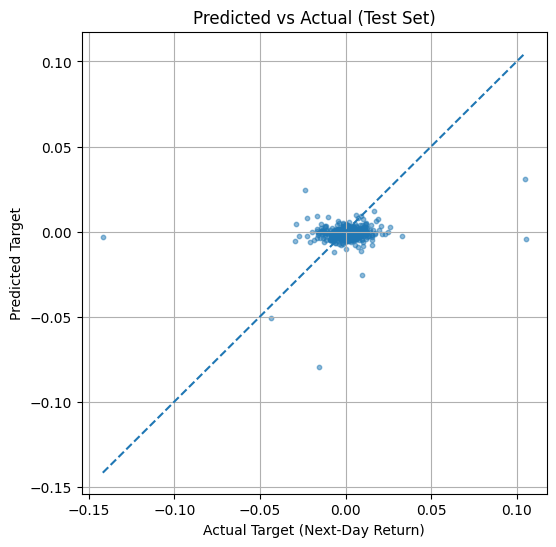

In [17]:
# 6.2 Plot predicted vs actual (test set) with a 45-degree line

def plot_predicted_vs_actual(y_true, y_pred, title="Predicted vs Actual (Test Set)"):
    """
    Scatter plot of predicted vs actual values with a y=x reference line.
    """
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, s=10)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual Target (Next-Day Return)")
    plt.ylabel("Predicted Target")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_predicted_vs_actual(y_test, y_test_pred)

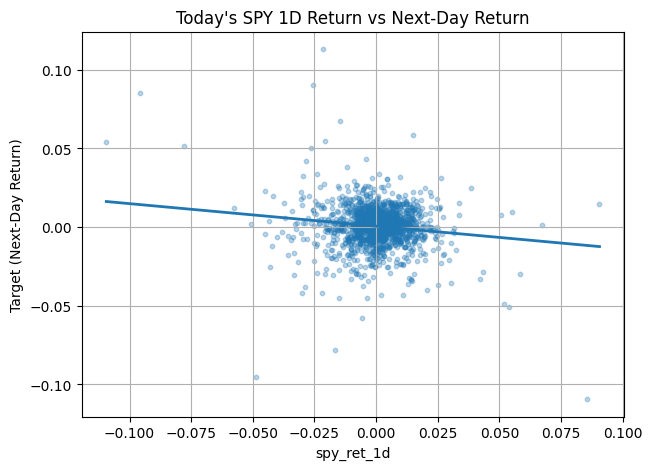

In [18]:
# 6.3 Plot a feature vs the target with a best-fit line

def plot_feature_vs_target(X, y, feature_name, title=None):
    """
    Plot a scatter of one feature vs the target with a best-fit linear regression line.

    Parameters
    ----------
    X : pd.DataFrame
    y : pd.Series
    feature_name : str
        Column name of the feature to plot.
    title : str or None
        Optional plot title.
    """
    if title is None:
        title = f"{feature_name} vs Target"

    x = X[feature_name]
    mask = x.notna() & y.notna()
    x_vals = x[mask]
    y_vals = y[mask]

    plt.figure(figsize=(7, 5))
    plt.scatter(x_vals, y_vals, alpha=0.3, s=10)

    # Fit a simple linear regression (using numpy.polyfit) for the line
    if len(x_vals) > 1:
        slope, intercept = np.polyfit(x_vals, y_vals, 1)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        y_line = slope * x_line + intercept
        plt.plot(x_line, y_line, linewidth=2)

    plt.xlabel(feature_name)
    plt.ylabel("Target (Next-Day Return)")
    plt.title(title)
    plt.grid(True)
    plt.show()


# Example: visualize relationship between today's SPY 1-day return and next-day return
plot_feature_vs_target(X_train, y_train, feature_name="spy_ret_1d", 
                       title="Today's SPY 1D Return vs Next-Day Return")

### 6.4 Brief Interpretation

- If **SSE, MSE, RMSE** are small (relative to the typical magnitude of SPY daily returns), the linear model might be capturing some signal.
- If **R²** is close to 0, it suggests the model does not explain much variance in next-day returns (which is fairly common for simple linear models on daily equity returns).
- The **predicted vs actual plot**:
  - Points tightly clustered around the 45° line indicate a better fit.
  - A wide scatter suggests weak predictive power.
- The **feature vs target plot** helps visually check if there is an approximately linear relationship between a given feature (e.g. `spy_ret_1d`) and the next-day return.
  - A nearly flat best-fit line suggests little linear relationship.
  - A slope significantly away from zero suggests some linear dependency.

Keep in mind that equity returns are noisy and hard to predict; this model is intentionally simple and mainly serves as an educational example.

In [19]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

def evaluate_buy_sell_classification(model, X, y, dataset_name=""):
    """Evaluate BUY/SELL decisions based on the sign of predicted vs actual returns.

    Parameters
    ----------
    model : fitted sklearn estimator
        Regression model that predicts next-day returns.
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series or array-like
        True next-day returns.
    dataset_name : str
        Label for printing (e.g. 'Train' or 'Test').

    Returns
    -------
    result : dict
        Dictionary containing predictions, labels, confusion matrix and metrics.
    """
    # 1) Get regression predictions
    y_reg = model.predict(X)

    # 2) Convert to binary BUY/SELL labels
    # BUY (1) if return > 0, SELL (0) otherwise
    y_true_cls = (y > 0).astype(int)
    y_pred_cls = (y_reg > 0).astype(int)

    # 3) Confusion matrix and basic counts
    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # 4) Metrics
    accuracy = accuracy_score(y_true_cls, y_pred_cls)
    precision = precision_score(y_true_cls, y_pred_cls, zero_division=0)
    recall = recall_score(y_true_cls, y_pred_cls, zero_division=0)   # sensitivity / TPR
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")  # TNR
    f1 = f1_score(y_true_cls, y_pred_cls, zero_division=0)

    # 5) Format as tables
    cm_df = pd.DataFrame(
        cm,
        index=pd.Index(["Actual SELL (0)", "Actual BUY (1)"], name="Actual"),
        columns=pd.Index(["Pred SELL (0)", "Pred BUY (1)"], name="Predicted"),
    )

    metrics_df = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Precision (PPV)",
                "Sensitivity (Recall / TPR)",
                "Specificity (TNR)",
                "F1-score",
            ],
            "Value": [
                accuracy,
                precision,
                recall,
                specificity,
                f1,
            ],
        }
    ).set_index("Metric")

    print(f"\n=== BUY/SELL Classification Evaluation ({dataset_name}) ===")
    print("\nConfusion Matrix:")
    print(cm_df)
    print("\nMetrics:")
    print(metrics_df)

    return {
        "y_reg": y_reg,
        "y_true_cls": y_true_cls,
        "y_pred_cls": y_pred_cls,
        "confusion_matrix": cm_df,
        "metrics": metrics_df,
    }

# Run classification-style evaluation on both train and test sets
train_class_results = evaluate_buy_sell_classification(
    final_model, X_train, y_train, dataset_name="Train"
)

test_class_results = evaluate_buy_sell_classification(
    final_model, X_test, y_test, dataset_name="Test"
)



=== BUY/SELL Classification Evaluation (Train) ===

Confusion Matrix:
Predicted        Pred SELL (0)  Pred BUY (1)
Actual                                      
Actual SELL (0)            430           488
Actual BUY (1)             443           634

Metrics:
                               Value
Metric                              
Accuracy                    0.533333
Precision (PPV)             0.565062
Sensitivity (Recall / TPR)  0.588672
Specificity (TNR)           0.468410
F1-score                    0.576626

=== BUY/SELL Classification Evaluation (Test) ===

Confusion Matrix:
Predicted        Pred SELL (0)  Pred BUY (1)
Actual                                      
Actual SELL (0)            140            65
Actual BUY (1)             186           107

Metrics:
                               Value
Metric                              
Accuracy                    0.495984
Precision (PPV)             0.622093
Sensitivity (Recall / TPR)  0.365188
Specificity (TNR)           0.68292

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 6.6.1 Build binary UP/DOWN labels from the regression target
# 1 = next-day return > 0 (UP/BULLISH -> BUY), 0 = otherwise (DOWN/FLAT -> SELL)

y_train_cls = (y_train > 0).astype(int)
y_test_cls  = (y_test > 0).astype(int)

print("Class balance (Train):")
print(y_train_cls.value_counts(normalize=True).rename("proportion"))
print("\nClass balance (Test):")
print(y_test_cls.value_counts(normalize=True).rename("proportion"))

# 6.6.2 Logistic Regression pipeline with standardization
def create_logistic_pipeline():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(
                penalty="l2",
                max_iter=2000,
                class_weight="balanced",  # helps if UP vs DOWN is imbalanced
                solver="lbfgs"
            ))
        ]
    )

# 6.6.3 Time-series aware CV + GridSearch over C (regularization strength)
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    "logreg__C": [0.01, 0.1, 1.0, 10.0, 100.0],
}

logreg_grid = GridSearchCV(
    estimator=create_logistic_pipeline(),
    param_grid=param_grid,
    cv=tscv,
    scoring="f1",      # optimise balanced precision/recall
    n_jobs=-1,
    refit=True         # refit best model on full training set
)

logreg_grid.fit(X_train, y_train_cls)

best_log_model = logreg_grid.best_estimator_
print("\nBest logistic C (from CV):", logreg_grid.best_params_["logreg__C"])
print("Best mean CV F1:", logreg_grid.best_score_)


Class balance (Train):
target_spy_fwd_ret
1    0.53985
0    0.46015
Name: proportion, dtype: float64

Class balance (Test):
target_spy_fwd_ret
1    0.588353
0    0.411647
Name: proportion, dtype: float64



Best logistic C (from CV): 10.0
Best mean CV F1: 0.48073627295746696


In [21]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

def evaluate_logistic_buy_sell(model, X, y_cls, dataset_name="", threshold=0.5):
    """
    Evaluate a logistic regression directional model (BUY/SELL) at a given threshold.

    Parameters
    ----------
    model : fitted sklearn Pipeline with LogisticRegression
    X : pd.DataFrame
    y_cls : pd.Series (0/1)
        True class labels: 1 = UP (BUY), 0 = DOWN (SELL).
    dataset_name : str
        Label for printing (e.g. 'Train' or 'Test').
    threshold : float
        Probability cutoff for predicting class 1 (BUY).

    Returns
    -------
    result : dict
        Contains probabilities, labels, confusion matrix and metrics.
    """
    # Predicted probability of class 1 (UP)
    proba = model.predict_proba(X)[:, 1]
    y_pred = (proba >= threshold).astype(int)

    cm = confusion_matrix(y_cls, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_cls, y_pred)
    precision = precision_score(y_cls, y_pred, zero_division=0)
    recall = recall_score(y_cls, y_pred, zero_division=0)   # sensitivity / TPR
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    f1 = f1_score(y_cls, y_pred, zero_division=0)

    cm_df = pd.DataFrame(
        cm,
        index=pd.Index(["Actual SELL (0)", "Actual BUY (1)"], name="Actual"),
        columns=pd.Index(["Pred SELL (0)", "Pred BUY (1)"], name="Predicted"),
    )

    metrics_df = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Precision (PPV)",
                "Sensitivity (Recall / TPR)",
                "Specificity (TNR)",
                "F1-score",
            ],
            "Value": [
                accuracy,
                precision,
                recall,
                specificity,
                f1,
            ],
        }
    ).set_index("Metric")

    print(f"\n=== Logistic BUY/SELL Evaluation ({dataset_name}) @ threshold={threshold:.2f} ===")
    print("\nConfusion Matrix:")
    print(cm_df)
    print("\nMetrics:")
    print(metrics_df)

    return {
        "proba": proba,
        "y_true_cls": y_cls,
        "y_pred_cls": y_pred,
        "confusion_matrix": cm_df,
        "metrics": metrics_df,
    }

# Evaluate logistic model on Train and Test with default 0.5 threshold
log_train_results = evaluate_logistic_buy_sell(
    best_log_model, X_train, y_train_cls, dataset_name="Train", threshold=0.5
)
log_test_results = evaluate_logistic_buy_sell(
    best_log_model, X_test, y_test_cls, dataset_name="Test", threshold=0.5
)



=== Logistic BUY/SELL Evaluation (Train) @ threshold=0.50 ===

Confusion Matrix:
Predicted        Pred SELL (0)  Pred BUY (1)
Actual                                      
Actual SELL (0)            529           389
Actual BUY (1)             441           636

Metrics:
                               Value
Metric                              
Accuracy                    0.583960
Precision (PPV)             0.620488
Sensitivity (Recall / TPR)  0.590529
Specificity (TNR)           0.576253
F1-score                    0.605138

=== Logistic BUY/SELL Evaluation (Test) @ threshold=0.50 ===

Confusion Matrix:
Predicted        Pred SELL (0)  Pred BUY (1)
Actual                                      
Actual SELL (0)            183            22
Actual BUY (1)             246            47

Metrics:
                               Value
Metric                              
Accuracy                    0.461847
Precision (PPV)             0.681159
Sensitivity (Recall / TPR)  0.160410
Specificity (

In [22]:
def find_best_threshold(y_true_cls, proba, metric="f1", thresholds=None):
    """
    Search over thresholds and find the one that maximizes a chosen metric.

    Parameters
    ----------
    y_true_cls : array-like (0/1)
    proba : array-like
        Predicted probabilities for class 1 (BUY).
    metric : str
        'f1' or 'accuracy'.
    thresholds : array-like or None
        Thresholds to search. If None, uses np.linspace(0.3, 0.7, 41).

    Returns
    -------
    best_thr : float
    best_val : float
    """
    if thresholds is None:
        thresholds = np.linspace(0.3, 0.7, 41)  # focus around 0.5

    best_thr = 0.5
    best_val = -np.inf

    for thr in thresholds:
        y_pred = (proba >= thr).astype(int)
        if metric == "f1":
            val = f1_score(y_true_cls, y_pred, zero_division=0)
        elif metric == "accuracy":
            val = accuracy_score(y_true_cls, y_pred)
        else:
            raise ValueError("Unsupported metric: use 'f1' or 'accuracy'.")

        if val > best_val:
            best_val = val
            best_thr = thr

    return best_thr, best_val

# 6.6.4 Find best threshold on TRAIN based on F1
best_thr, best_f1 = find_best_threshold(
    y_true_cls=log_train_results["y_true_cls"],
    proba=log_train_results["proba"],
    metric="f1"
)

print(f"\nBest threshold on TRAIN (by F1): {best_thr:.3f}, F1={best_f1:.4f}")

# Re-evaluate Train and Test at this tuned threshold
log_train_results_tuned = evaluate_logistic_buy_sell(
    best_log_model, X_train, y_train_cls,
    dataset_name="Train (tuned)", threshold=best_thr
)
log_test_results_tuned = evaluate_logistic_buy_sell(
    best_log_model, X_test, y_test_cls,
    dataset_name="Test (tuned)", threshold=best_thr
)





Best threshold on TRAIN (by F1): 0.330, F1=0.7081

=== Logistic BUY/SELL Evaluation (Train (tuned)) @ threshold=0.33 ===

Confusion Matrix:
Predicted        Pred SELL (0)  Pred BUY (1)
Actual                                      
Actual SELL (0)             61           857
Actual BUY (1)              17          1060

Metrics:
                               Value
Metric                              
Accuracy                    0.561905
Precision (PPV)             0.552947
Sensitivity (Recall / TPR)  0.984215
Specificity (TNR)           0.066449
F1-score                    0.708083

=== Logistic BUY/SELL Evaluation (Test (tuned)) @ threshold=0.33 ===

Confusion Matrix:
Predicted        Pred SELL (0)  Pred BUY (1)
Actual                                      
Actual SELL (0)             41           164
Actual BUY (1)              49           244

Metrics:
                               Value
Metric                              
Accuracy                    0.572289
Precision (PPV)     

## 7. Inference Pipeline (BUY/SELL Decision)

Now we build a **production-style inference function** `run_inference()` that:

1. Downloads **recent data** from Yahoo Finance.
2. Recomputes **base features** and **lagged features** exactly as in training.
3. Extracts the most recent feature row with the same column order as `feature_columns`.
4. Uses the trained model to predict the **next-day close-to-close return**.
5. Maps this return to:
   - A predicted 9:30 price (we approximate this as today’s close).
   - A predicted 4:00 pm price on the next trading day.
6. Constructs a **BUY/SELL signal**:
   - If predicted 4pm price > predicted 9:30 price → `"BUY"`.
   - Else → `"SELL"`.

> **Note on mapping to 9:30 and 4:00 prices**  
> - Target \\( y \\) is the **next-day close-to-close return**:  
>   \\( y_{t+1} = C_{t+1} / C_t - 1 \\).  
> - At inference we:
>   - Approximate the next day’s 9:30 price by today’s close \\( C_t \\).
>   - Predict \\( C_{t+1} = C_t \cdot (1 + \hat{y}_{t+1}) \\).
> - This ignores overnight gaps and is just a rough approximation for educational use.

In [23]:
# 7.1 Inference function
def run_inference_v2(
    linear_model,
    logistic_model,
    feature_columns,
    threshold,
    tickers=TICKERS,
    start_date="2015-01-01",
    end_date=None,
    lags=LAGS,
    require_positive_return=True,
):
    """
    Inference pipeline (v2):
      - Linear regression --> next-day return magnitude.
      - Logistic regression --> probability next day is UP.
      - BUY/SELL decided from logistic prob (and optionally sign of linear prediction).

    Parameters
    ----------
    linear_model : fitted sklearn estimator
        Regression model for next-day return (final_model).
    logistic_model : fitted sklearn estimator
        Classification model for UP/DOWN (best_log_model).
    feature_columns : list[str]
        Column names used for training.
    threshold : float
        Probability cutoff for predicting BUY (class 1).
    tickers : dict
        Ticker mapping.
    start_date, end_date : str
        History window for features.
    lags : list[int]
        Lags used when training.
    require_positive_return : bool
        If True, require BOTH prob_up >= threshold AND predicted return > 0
        to issue BUY; otherwise SELL.

    Returns
    -------
    result : dict
        Prediction summary and signal.
    """
    # 1) Download fresh data
    recent_raw = download_price_data(
        tickers,
        start_date=start_date,
        end_date=end_date,
        auto_adjust=True
    )
    
    # 2) Recompute base + lagged features
    recent_base, recent_spy_close = compute_base_features(recent_raw)
    recent_lagged = add_lagged_features(recent_base, lags=lags)
    recent_lagged = recent_lagged.dropna()

    # 3) Align to training feature columns
    missing_cols = [c for c in feature_columns if c not in recent_lagged.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in inference features: {missing_cols}")

    X_all = recent_lagged[feature_columns].dropna()

    # Latest row = most recent trading day
    latest_features = X_all.iloc[-1:]
    latest_date = latest_features.index[0]

    # 4) Linear regression prediction for next-day return
    pred_ret = float(linear_model.predict(latest_features)[0])

    # 5) Logistic prediction for probability of UP (BUY)
    prob_up = float(logistic_model.predict_proba(latest_features)[0, 1])

    # 6) Map predicted return to prices (as before)
    latest_spy_close = float(recent_spy_close.reindex(recent_lagged.index).iloc[-1])
    pred_open_930 = latest_spy_close
    pred_close_1600 = pred_open_930 * (1.0 + pred_ret)
    pred_intraday_change = pred_close_1600 - pred_open_930

    # 7) Decide signal
    if require_positive_return:
        if (prob_up >= threshold) and (pred_ret > 0):
            signal = "BUY"
        else:
            signal = "SELL"
    else:
        signal = "BUY" if prob_up >= threshold else "SELL"

    # 8) Package result
    result = {
        "signal_date": latest_date,
        "prob_up": prob_up,
        "threshold": threshold,
        "pred_open_930": pred_open_930,
        "pred_close_1600": pred_close_1600,
        "pred_intraday_change": pred_intraday_change,
        "pred_intraday_return": pred_ret,
        "signal": signal,
    }

    return result



In [24]:
inference_result_v2 = run_inference_v2(
    linear_model=final_model,
    logistic_model=best_log_model,
    feature_columns=feature_columns,
    threshold=best_thr,          # tuned on training F1
    start_date="2018-01-01",
    require_positive_return=True # require both prob_up and positive predicted return
)

print("=== Inference Result v2 (Educational) ===")
print(f"Signal date (features as of): {inference_result_v2['signal_date'].date()}")
print(f"Probability next day is UP:  {inference_result_v2['prob_up']:.3f}")
print(f"Threshold used:              {inference_result_v2['threshold']:.3f}")
print(f"Predicted 9:30 price:        {inference_result_v2['pred_open_930']:.2f}")
print(f"Predicted 16:00 price:       {inference_result_v2['pred_close_1600']:.2f}")
print(f"Predicted intraday change:   {inference_result_v2['pred_intraday_change']:.4f}")
print(f"Predicted intraday return:   {inference_result_v2['pred_intraday_return']:.6f}")
print(f"Final trading signal:        {inference_result_v2['signal']}")


=== Inference Result v2 (Educational) ===
Signal date (features as of): 2025-11-21
Probability next day is UP:  0.437
Threshold used:              0.330
Predicted 9:30 price:        659.03
Predicted 16:00 price:       657.40
Predicted intraday change:   -1.6348
Predicted intraday return:   -0.002481
Final trading signal:        SELL


### 7.3 Interpretation of the Signal

- If the model expects the next-day close > (approximate) open, the signal is **BUY**.
- If the model expects the next-day close ≤ open, the signal is **SELL**.
- This is only a **toy example**:
  - No transaction costs.
  - No slippage.
  - No position sizing or risk management.
  - No execution logic.

In a real system, you would:
- Validate robustness on out-of-sample periods.
- Incorporate costs and constraints.
- Use more sophisticated models and evaluation techniques.

## 8. Saving Artifacts (Model + Requirements)

Finally, we:

1. Save the trained model and associated metadata (feature names, lags) to a `.pkl` file:
   - `spy_intraday_linear_model.pkl`
2. Programmatically create a `requirements.txt` file listing the core Python packages needed to run this notebook.

In [25]:
# 8.1 Save model artifact as a pickle

artifact = {
    "model": final_model,
    "feature_columns": feature_columns,
    "lags": LAGS,
    "train_start_date": start_date,
    "created_at": datetime.utcnow().isoformat() + "Z",
}

artifact_filename = "spy_intraday_linear_model.pkl"
with open(artifact_filename, "wb") as f:
    pickle.dump(artifact, f)

print(f"Saved model artifact to: {os.path.abspath(artifact_filename)}")

Saved model artifact to: /Users/jamesoon/Library/Mobile Documents/com~apple~CloudDocs/Desktop/PROJECTS/SUTD/MSTR-DAIE/MLOPS/Project/ml_source/spy_intraday_linear_model.pkl


In [26]:
# 8.2 Generate a simple requirements.txt

required_packages = [
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "yfinance"
]

req_filename = "requirements.txt"
with open(req_filename, "w") as f:
    f.write("\n".join(required_packages))

print(f"Generated requirements file at: {os.path.abspath(req_filename)}")

Generated requirements file at: /Users/jamesoon/Library/Mobile Documents/com~apple~CloudDocs/Desktop/PROJECTS/SUTD/MSTR-DAIE/MLOPS/Project/ml_source/requirements.txt
